### Imports

In [2]:
%load_ext autoreload
%autoreload 2
import os
import shutil
import hydra
from omegaconf import OmegaConf
from scipy.spatial.transform import Rotation as R
import pathlib
import wandb
import torch
import tqdm
import dill
import json
import numpy as np
import datetime
import matplotlib.pyplot as plt
from diffusion_policy.workspace.base_workspace import BaseWorkspace
from diffusion_policy.env.two_finger.two_finger_gym_env_image import TwoFingerGoalEnvImage
from diffusion_policy.env_runner.two_finger_image_runner import TwoFingerImageRunner
from diffusion_policy.policy.diffusion_unet_hybrid_image_policy import DiffusionUnetHybridImagePolicy

os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["MUJOCO_GL"] = "egl"
os.environ["DISPLAY"] = ":1"
PROJECT_ROOT = pathlib.Path('').resolve().parent
cfg = OmegaConf.load(os.path.join(PROJECT_ROOT, 'config', 'image_two_finger_box_qpos_cnn.yaml'))
cfg = OmegaConf.create(cfg)
date_str = datetime.datetime.now().strftime("%Y.%m.%d.%H.%M.%S")

QPOS_CKPT_PATH = os.path.join("/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.16/17.29.39_train_diffusion_unet_hybrid_two_finger_box_qpos/checkpoints/latest.ckpt")
QVEL_CKPT_PATH = os.path.join("/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.12/13.28.14_train_diffusion_unet_hybrid_two_finger_box_qvel/checkpoints/epoch=0100-test_mean_score=32.843.ckpt")
STATELESS_CKPT_PATH = os.path.join("/data/scene-rep/u/iyu/scene-jacobian-discovery/diff-policy/diffusion_policy/data/outputs/2025.04.04/12.18.30_train_diffusion_unet_hybrid_two_finger_box_stateless/checkpoints/latest.ckpt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# policy = hydra.utils.instantiate(cfg.policy)
# env_runner = hydra.utils.instantiate(cfg.task.env_runner, output_dir=None)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def z_rotation_to_quat(z):
    rot = R.from_euler("xyz", [0, 0, z], degrees=True)
    rot_quat = rot.as_quat()
    rot_quat = rot_quat / np.linalg.norm(rot_quat)
    # reorder to [w, x, y, z]
    rot_quat = np.roll(rot_quat, 1)
    return rot_quat

def quat_to_z_rotation(quat):
    rot = R.from_quat(quat, scalar_first=True)
    rot_z = rot.as_euler('xyz', degrees=True)[:, -1]
    return rot_z

def main(checkpoint, output_dir, device="cuda", num_angles=10, n_evals=1):
    if os.path.exists(output_dir):
        # remove the directory if it exists
        shutil.rmtree(output_dir)
    pathlib.Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # load checkpoint
    payload = torch.load(open(checkpoint, 'rb'), pickle_module=dill)
    cfg = payload['cfg']
    cls = hydra.utils.get_class(cfg._target_)
    workspace = cls(cfg, output_dir=output_dir)
    workspace: BaseWorkspace
    workspace.load_payload(payload, exclude_keys=None, include_keys=None)
    
    # get policy from workspace
    policy = workspace.model
    if cfg.training.use_ema:
        policy = workspace.ema_model
    
    device = torch.device(device)
    policy.to(device)
    policy.eval()
    # override cfg.task.env_runner
    env_kwargs = {
        "arm_type": "shadow",
        "render_mode": "rgb_array",
        "camera_name": "birdview",
        "default_camera_config": None,
        "relative_control": True,
        "actuation_scale": 1.0,
        "target_position_mode": "ignore",
        "target_rotation_mode": "fixed",
        "target_position_range": np.array([(-0.02, 0.00), (-0.02, 0.02), (0.0, 0.0)]),
        "reward_type": "dense",
        "render_target": False,
        "n_substeps": 10,
        "randomize_initial_position": True,
        "randomize_initial_rotation": True,
        "fixed_initial_pos": None,
        "fixed_initial_quat": np.array([0.146531, 0.0, 0.0, -0.989206])
    }
    cfg.task.env_runner.n_test = n_evals
    cfg.task.env_runner.n_train = 0
    cfg.task.env_runner.max_steps = 800
    runner_logs = []
    # run eval
    for i in range(num_angles):
        env_kwargs_i = env_kwargs.copy()
        quat = z_rotation_to_quat(i / num_angles * 360)
        print(f"Running eval for angle {i} / {num_angles} with quat {quat}")
        env_kwargs_i["fixed_initial_quat"] = quat
        env_runner = hydra.utils.instantiate(
            cfg.task.env_runner,
            env_kwargs=env_kwargs_i,
            output_dir=output_dir)
        runner_log = env_runner.run(policy)
        runner_logs.append(runner_log)
    
    # dump log to json
    json_logs = {}
    for i, runner_log in enumerate(runner_logs):
        json_log = dict()
        for key, value in runner_log.items():
            if isinstance(value, wandb.sdk.data_types.video.Video):
                json_log[key] = value._path
            else:
                json_log[key] = value
        json_logs[i / num_angles * 3600] = json_log
    out_path = os.path.join(output_dir, 'eval_log.json')
    json.dump(json_logs, open(out_path, 'w'), indent=2, sort_keys=True)
    return json_logs

In [4]:
output_dir_names = ["qpos", "qvel", "stateless"]
OUTPUT_DIRS = [pathlib.Path(PROJECT_ROOT.parent, "data", "outputs", "eval_shadow_finger", output_dir_names[i]) for i in range(len(output_dir_names))]
CKPT_PATHS = [
    QPOS_CKPT_PATH,
    QVEL_CKPT_PATH,
    STATELESS_CKPT_PATH
]
num_angles = 10
n_evals = 16
json_logs = {}
for cond_name, output_dir, ckpt_path in zip(output_dir_names, OUTPUT_DIRS, CKPT_PATHS):
    json_log = main(ckpt_path, output_dir, device="cuda", n_evals=n_evals, num_angles=num_angles)
    json_logs[cond_name] = json_log


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
Diffusion params: 1.741056e+07
Vision params: 1.119709e+07
Running eval for angle 0 / 10 with quat [1. 0. 0. 0.]


Running eval for angle 1 / 10 with quat [0.95105652 0.         0.         0.30901699]


Running eval for angle 2 / 10 with quat [0.80901699 0.         0.         0.58778525]


Running eval for angle 3 / 10 with quat [0.58778525 0.         0.         0.80901699]


Running eval for angle 4 / 10 with quat [0.30901699 0.         0.         0.95105652]


...

Running eval for angle 5 / 10 with quat [6.123234e-17 0.000000e+00 0.000000e+00 1.000000e+00]


Running eval for angle 6 / 10 with quat [-0.30901699  0.          0.          0.95105652]


Running eval for angle 7 / 10 with quat [-0.58778525  0.          0.          0.80901699]


Running eval for angle 8 / 10 with quat [-0.80901699  0.          0.          0.58778525]


Running eval for angle 9 / 10 with quat [-0.95105652  0.          0.          0.30901699]


{'qpos': {0.0: {'test/sim_max_reward_100000': 248.17986717166818, 'test/sim_end_reward_100000': 248.0341781645648, 'test/sim_max_reward_100001': 248.15888164855573, 'test/sim_end_reward_100001': 248.09343896776946, 'test/sim_max_reward_100002': 248.1963707562379, 'test/sim_end_reward_100002': 248.19627029874874, 'test/sim_max_reward_100003': 248.16055157844127, 'test/sim_end_reward_100003': 248.1051184337852, 'test/sim_max_reward_100004': 248.17166519921832, 'test/sim_end_reward_100004': 248.17155526805908, 'test/sim_max_reward_100005': 248.175207829997, 'test/sim_end_reward_100005': 248.17493064435547, 'test/sim_max_reward_100006': 248.17897013174272, 'test/sim_end_reward_100006': 248.17858311262472, 'test/sim_max_reward_100007': 248.18394456281186, 'test/sim_end_reward_100007': 248.16092265298596, 'test/sim_max_reward_100008': 248.18046357041567, 'test/sim_end_reward_100008': 248.18042623839742, 'test/sim_max_reward_100009': 248.22683264608176, 'test/sim_end_reward_100009': 248.22641

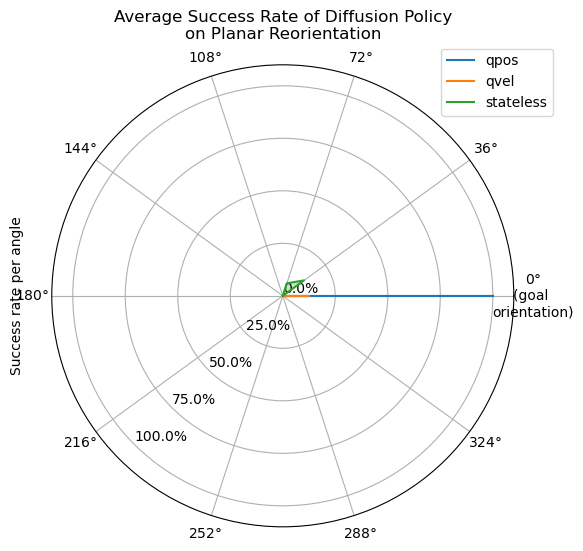

In [28]:
print(json_logs)
# for each key, take the average reward
rewards_per_cond = {}
success_per_cond = {}
for cond_name, json_log in json_logs.items():
    avg_rewards = []
    avg_success = []
    for key, value in json_log.items():
        # key is the rotation angle
        # value is a dict
        # value["reward"] is the reward
        # value["video"] is the video path
        rewards = []
        for i in range(len(value)):
            # find the key that contains "reward"
            reward_key = [k for k in value.keys() if "end_reward" in k]
            for k in reward_key:
                rewards.append(value[k])
        avg_reward_per_angle = np.mean(rewards)
        avg_success_per_angle = np.mean(np.array(rewards) > 160, axis=-1)
        print(f"average end reward for angle {key} is {avg_reward_per_angle}")
        avg_rewards.append(avg_reward_per_angle / 250. * 100.)
        avg_success.append(avg_success_per_angle * 100.)
    rewards_per_cond[cond_name] = avg_rewards
    success_per_cond[cond_name] = avg_success
# plot the rewards in polar chart with angles as labels
print(rewards_per_cond)
angles = np.linspace(0, 2 * np.pi, num_angles, endpoint=False)  # Use radians for polar plots
angles = np.concatenate((angles, [angles[0]]))  # Close the loop

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for cond_name, avg_success in success_per_cond.items():
    
    avg_success = np.concatenate((avg_success, [avg_success[0]]))  # Close the reward loop
    ax.plot(angles, avg_success, label=cond_name)
    ax.fill(angles, avg_success, alpha=0.25)

# Set angle ticks
tick_angles = np.linspace(0, 360, num_angles, endpoint=False)
ax.set_xticks(np.linspace(0, 2 * np.pi, num_angles, endpoint=False))
x_tick_labels = [r"${:.0f}\degree$".format(int(angle)) for angle in tick_angles]
x_tick_labels[0] = r"$0\degree$"+"\n(goal \norientation)"
ax.set_xticklabels(x_tick_labels)

# max_reward = max([max(avg_rewards) for avg_rewards in rewards_per_cond.values()])
ax.set_ylim(0, 100 * 1.1)  # Set the radius limits
y_tick_labels = [str(i) + "%" for i in np.linspace(0, 100, 5)]
ax.set_yticks(np.linspace(0, 100, 5))  # [0. , 0.25, 0.5 , 0.75, 1. ]
ax.set_yticklabels(y_tick_labels)
ax.set_rlabel_position(225)  # angle for label placement (in degrees)
ax.set_ylabel("Success rate per angle", labelpad=20)

ax.set_title("Average Success Rate of Diffusion Policy\non Planar Reorientation", va='bottom')
# subtitle
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.05))

plt.show()